In [1]:
# Import dependencies
import gc
import pandas as pd
from datetime import datetime, timedelta
import numpy as np
import seaborn as sns
import plotly.express as px

import matplotlib.pyplot as plt
import squarify
import matplotlib.cm as cm

import plotly.io as pio

In [2]:
# Display settings for better readability
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', 10)  # Display only the first 10 rows in output

In [2]:
# Load the Salesforce report exports from Excel files
lossrsn_df = pd.read_excel('SFLossReasonsEvaluation.xlsx')  # Read default sheet for opportunities

In [3]:
# read all column names and show all below
print(lossrsn_df.columns.tolist())

['Id', 'Price', 'Inventory', 'Quality Issues', 'Product Performance Issues', 'Customer Loyalty to Competitor', 'Aggressive Competitor Marketing or Discounts', 'No Budget/Lost Funding', 'Delayed Response from Internal Team', 'Proposal Did Not Address Customer Needs', 'Project Postponed', 'Lack of Demonstration or Trial', 'No Decision/Non-Responsive', 'Lost Contact with Decision Maker', 'Poor Lead Quality']


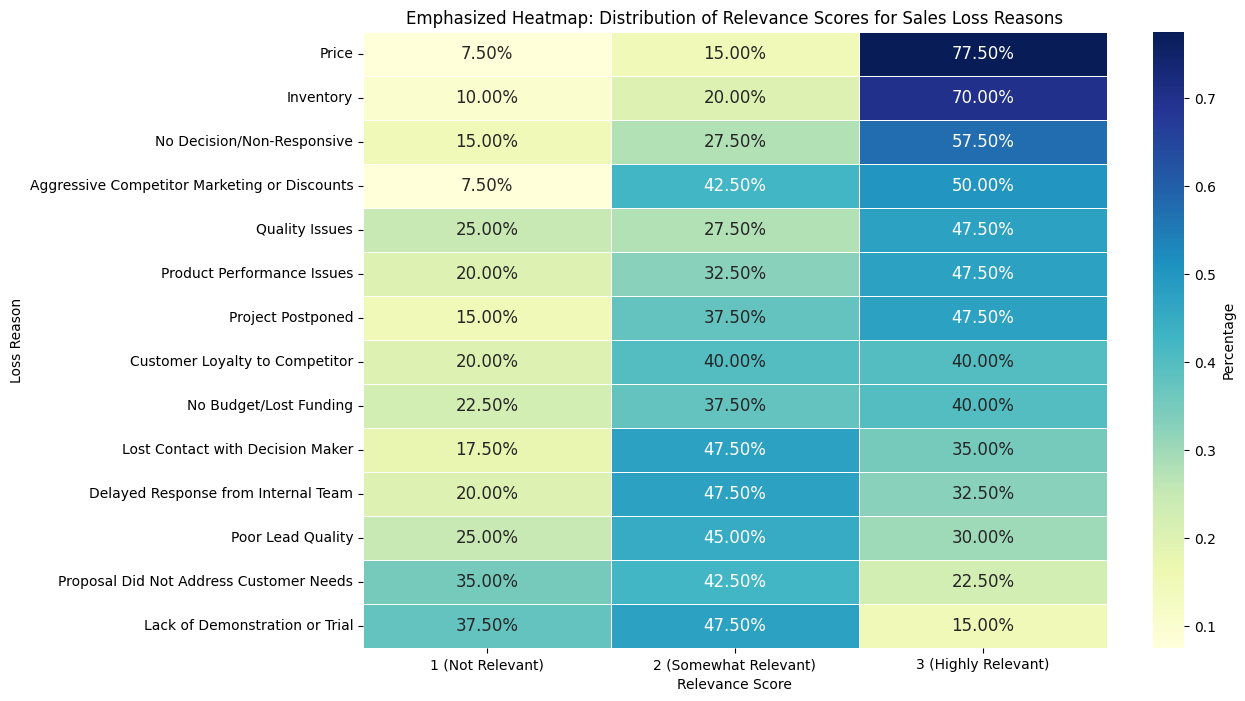

In [8]:
# Exclude only the 'Id' column
df_loss = lossrsn_df.drop(columns=['Id'])

# Count occurrences of each relevance level (1, 2, 3) for each loss reason
score_distribution = df_loss.apply(lambda x: x.value_counts(normalize=True)).T  # Normalize for percentage view

# Reorder columns to ensure correct X-axis labels
score_distribution = score_distribution[[1, 2, 3]]

# Sort rows by highest percentage of "Highly Relevant (3)" responses
score_distribution = score_distribution.sort_values(by=3, ascending=False)

# Create heatmap with a color scheme that highlights relevance better
plt.figure(figsize=(12, 8))
sns.heatmap(score_distribution, annot=True, cmap="YlGnBu", fmt=".2%", linewidths=0.5, annot_kws={"size": 12}, cbar_kws={'label': 'Percentage'})

# Adjust X-axis labels
plt.xticks(ticks=np.arange(3) + 0.5, labels=["1 (Not Relevant)", "2 (Somewhat Relevant)", "3 (Highly Relevant)"])

# Labels and title
plt.xlabel("Relevance Score")
plt.ylabel("Loss Reason")
plt.title("Emphasized Heatmap: Distribution of Relevance Scores for Sales Loss Reasons")

# Show plot
plt.show()


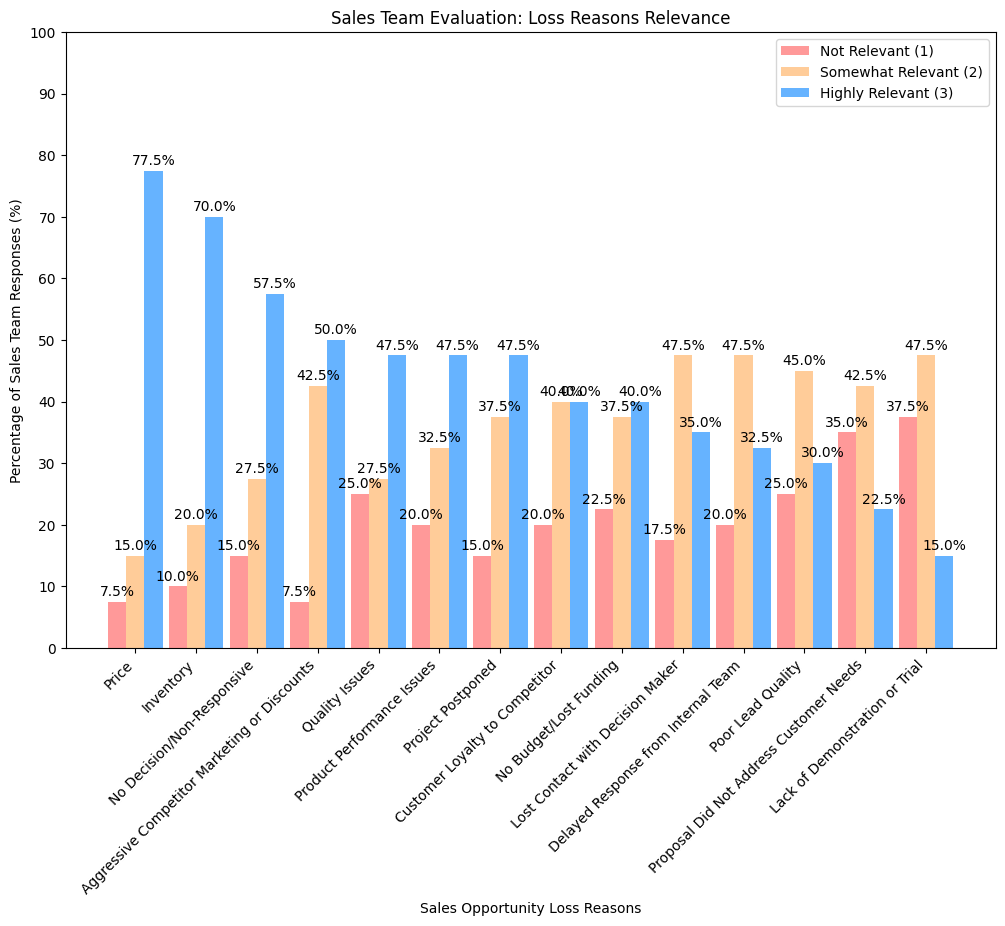

In [11]:
# Exclude only the 'Id' column
df_loss = lossrsn_df.drop(columns=['Id'])

# Count occurrences of each relevance level (1, 2, 3) for each loss reason
score_distribution = df_loss.apply(lambda x: x.value_counts(normalize=True) * 100).T  # Convert to percentage

# Ensure correct order of relevance levels
score_distribution = score_distribution[[1, 2, 3]]

# Sorting loss reasons based on highest "Highly Relevant (3)" responses
score_distribution = score_distribution.sort_values(by=3, ascending=False)

# Get labels and values for plotting
loss_reasons = score_distribution.index
not_relevant = score_distribution[1]
somewhat_relevant = score_distribution[2]
highly_relevant = score_distribution[3]

# Set positions for grouped bars
x = np.arange(len(loss_reasons))  # Number of loss reasons
width = 0.3  # Width of bars

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Plot bars for each category
bars1 = ax.bar(x - width, not_relevant, width, color='#ff9999', label="Not Relevant (1)")
bars2 = ax.bar(x, somewhat_relevant, width, color='#ffcc99', label="Somewhat Relevant (2)")
bars3 = ax.bar(x + width, highly_relevant, width, color='#66b3ff', label="Highly Relevant (3)")

# Add labels and title
ax.set_xlabel("Sales Opportunity Loss Reasons")
ax.set_ylabel("Percentage of Sales Team Responses (%)")
ax.set_title("Sales Team Evaluation: Loss Reasons Relevance")

# Set Y-axis to display percentages (0-100%)
ax.set_yticks(np.arange(0, 101, 10))  # Tick marks every 10%

# Add percentage labels on top of bars for better readability
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:  # Only label bars with values
            ax.text(bar.get_x() + bar.get_width()/2, height + 1, f"{height:.1f}%", ha='center', fontsize=10)

# Set X-axis labels
ax.set_xticks(x)
ax.set_xticklabels(loss_reasons, rotation=45, ha="right")

# Add legend
ax.legend()

# Show plot
plt.show()


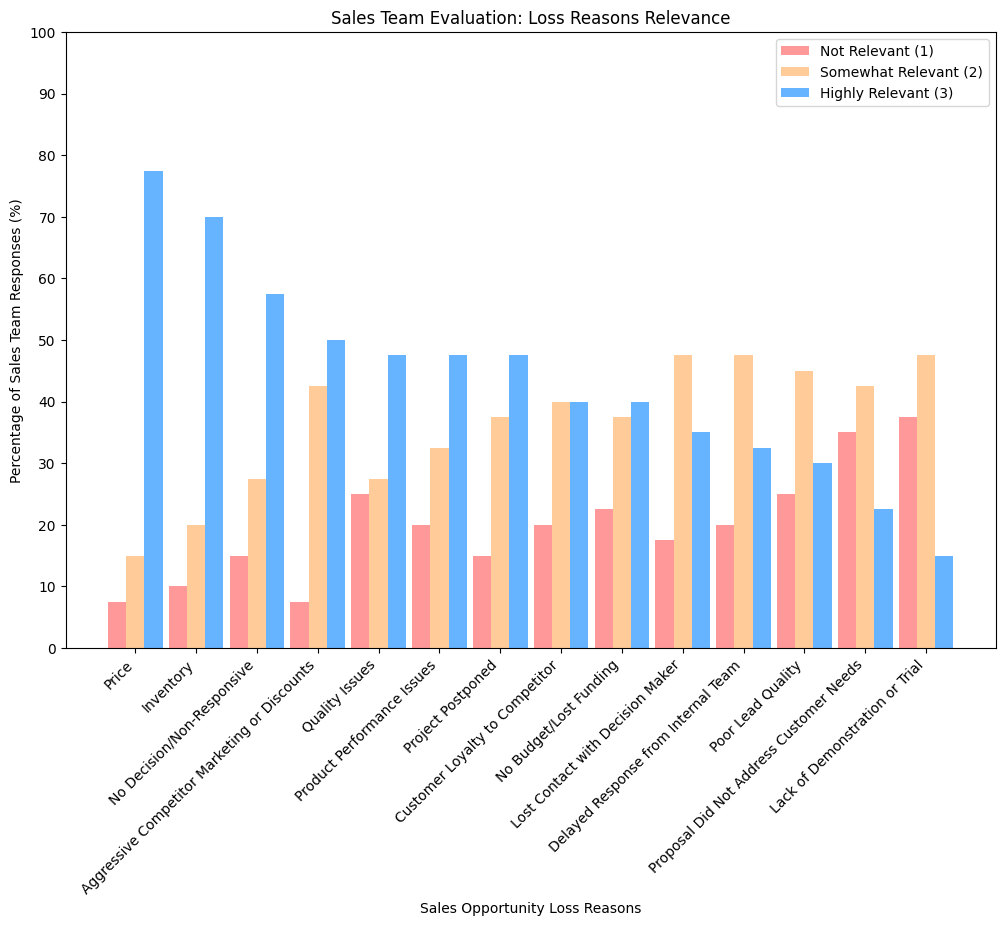

In [12]:
# Exclude only the 'Id' column
df_loss = lossrsn_df.drop(columns=['Id'])

# Count occurrences of each relevance level (1, 2, 3) for each loss reason
score_distribution = df_loss.apply(lambda x: x.value_counts(normalize=True) * 100).T  # Convert to percentage

# Ensure correct order of relevance levels
score_distribution = score_distribution[[1, 2, 3]]

# Sorting loss reasons based on highest "Highly Relevant (3)" responses
score_distribution = score_distribution.sort_values(by=3, ascending=False)

# Get labels and values for plotting
loss_reasons = score_distribution.index
not_relevant = score_distribution[1]
somewhat_relevant = score_distribution[2]
highly_relevant = score_distribution[3]

# Set positions for grouped bars
x = np.arange(len(loss_reasons))  # Number of loss reasons
width = 0.3  # Width of bars

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Plot bars for each category
ax.bar(x - width, not_relevant, width, color='#ff9999', label="Not Relevant (1)")
ax.bar(x, somewhat_relevant, width, color='#ffcc99', label="Somewhat Relevant (2)")
ax.bar(x + width, highly_relevant, width, color='#66b3ff', label="Highly Relevant (3)")

# Add labels and title
ax.set_xlabel("Sales Opportunity Loss Reasons")
ax.set_ylabel("Percentage of Sales Team Responses (%)")
ax.set_title("Sales Team Evaluation: Loss Reasons Relevance")

# Set Y-axis to display percentages (0-100%)
ax.set_yticks(np.arange(0, 101, 10))  # Tick marks every 10%

# Set X-axis labels
ax.set_xticks(x)
ax.set_xticklabels(loss_reasons, rotation=45, ha="right")

# Add legend
ax.legend()

# Show plot
plt.show()
